# HighRes-Net Inference (No HR Required)

Use this notebook when each sample has LR views only (no HR ground truth).

Purpose:
- Run 2x SR inference with low VRAM usage (8 GB friendly)
- Compare SR visually against bicubic baseline
- Preview results without requiring PSNR/SSIM

## 1. Setup and Imports

In [1]:
import sys
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage
from skimage import io

sys.path.insert(0, '../src')

import torch
from torch.utils.data import Dataset, DataLoader

from DeepNetworks.HRNet import HRNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch: 2.7.1+cu118
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB


## 2. Load Config and Model

In [2]:
config_path = Path('../config/config.json')
with open(config_path, 'r') as f:
    config = json.load(f)

model = HRNet(config['network']).to(device)
model.eval()

active_selection_path = Path('../models/weights/active_weight_selection.json')
legacy_weights_path = Path('../models/weights/HRNet.pth')
weights_path = None

if active_selection_path.exists():
    try:
        with open(active_selection_path, 'r') as f:
            active_payload = json.load(f)
        selected_path = Path(active_payload.get('path', ''))
        if selected_path.exists():
            weights_path = selected_path
            print(f'Loaded active selected weights: {weights_path}')
        else:
            print(f'Active selection points to missing file: {selected_path}')
    except Exception as e:
        print(f'Could not read active selection file: {e}')

if weights_path is None and legacy_weights_path.exists():
    weights_path = legacy_weights_path
    print(f'Loaded legacy fallback weights: {weights_path}')

if weights_path is None:
    raise FileNotFoundError(
        'No weight file available. Set one in notebooks/weights_manager.ipynb or create ../models/weights/HRNet.pth'
    )

state_dict = torch.load(str(weights_path), map_location=device)
model.load_state_dict(state_dict, strict=False)

Loaded active selected weights: D:\GUC\HighResNet model\HighRes-net\models\weights\CBAM\20260423_232605_base_CBAM new script.pth


<All keys matched successfully>

## 3. Define LR-Only Dataset (7 Views)

In [3]:
class LROnly7ViewDataset(Dataset):
    def __init__(self, sample_dirs, max_views=7):
        self.sample_dirs = [Path(p) for p in sample_dirs]
        self.max_views = max_views

    def __len__(self):
        return len(self.sample_dirs)

    def __getitem__(self, idx):
        sample_dir = self.sample_dirs[idx]
        lr_paths = sorted(glob.glob(str(sample_dir / 'LR_*.tif*')))
        if len(lr_paths) == 0:
            raise FileNotFoundError(f'No LR_*.tif/tiff found in {sample_dir}')

        lr_imgs = [io.imread(p).astype(np.float32) / 255.0 for p in lr_paths[:self.max_views]]
        lr_stack = np.stack(lr_imgs, axis=0)

        L, H, W = lr_stack.shape
        if L < self.max_views:
            pad = np.zeros((self.max_views - L, H, W), dtype=np.float32)
            lr_stack = np.concatenate([lr_stack, pad], axis=0)
            alpha = np.concatenate([np.ones(L, dtype=np.float32), np.zeros(self.max_views - L, dtype=np.float32)])
        else:
            alpha = np.ones(self.max_views, dtype=np.float32)

        return torch.from_numpy(lr_stack), torch.from_numpy(alpha), sample_dir.name

## 4. Configure Input Folder and DataLoader

In [4]:
dataset_root = Path('D:/GUC/Datasets/HighRes input test')
sample_dirs = sorted([d for d in dataset_root.iterdir() if d.is_dir() and d.name.startswith('image_')])
print(f'Found {len(sample_dirs)} sample folders')

dataset = LROnly7ViewDataset([str(d) for d in sample_dirs], max_views=config['training']['n_views'])
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f'DataLoader ready with batch_size=1')

Found 1 sample folders
DataLoader ready with batch_size=1


## 5. Tiled 2x Inference (Single Safe 8 GB Profile)

In [5]:
inference_cfg = {'tile_size': 160, 'halo': 96, 'use_amp': False}
print(f'Inference config: {inference_cfg}')

def tiled_forward_hrnet(model, lrs_cpu, alphas_cpu, device, tile_size=160, halo=96, use_amp=False):
    model.eval()
    outputs = []
    with torch.no_grad():
        B, _, H, W = lrs_cpu.shape
        step = int(tile_size)
        hctx = int(halo)
        amp_enabled = bool(use_amp and device.type == 'cuda')

        probe_h = min(64, H)
        probe_w = min(64, W)
        probe_lr = lrs_cpu[:1, :, :probe_h, :probe_w].to(device, non_blocking=True)
        probe_alpha = alphas_cpu[:1].to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
            probe_sr = model(probe_lr, probe_alpha)[:, 0]
        sy = max(1, int(round(probe_sr.shape[-2] / probe_h)))
        sx = max(1, int(round(probe_sr.shape[-1] / probe_w)))

        for b in range(B):
            sample = lrs_cpu[b:b+1]
            alpha = alphas_cpu[b:b+1]

            Hp = ((H + step - 1) // step) * step
            Wp = ((W + step - 1) // step) * step
            sample_grid = torch.nn.functional.pad(sample, (0, Wp - W, 0, Hp - H), mode='reflect')
            sample_ext = torch.nn.functional.pad(sample_grid, (hctx, hctx, hctx, hctx), mode='reflect')

            out_hp = Hp * sy
            out_wp = Wp * sx
            sr_acc = torch.zeros((1, out_hp, out_wp), dtype=torch.float32)
            sr_wgt = torch.zeros((1, out_hp, out_wp), dtype=torch.float32)

            for y0 in range(0, Hp, step):
                for x0 in range(0, Wp, step):
                    lr_tile = sample_ext[:, :, y0:y0 + step + 2 * hctx, x0:x0 + step + 2 * hctx].to(device, non_blocking=True)
                    alpha_tile = alpha.to(device, non_blocking=True)
                    with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
                        sr_tile = model(lr_tile, alpha_tile)[:, 0]
                    sr_tile = sr_tile.float().cpu()

                    cy0 = hctx * sy
                    cx0 = hctx * sx
                    crop = sr_tile[:, cy0:cy0 + step * sy, cx0:cx0 + step * sx]

                    ty0 = y0 * sy
                    tx0 = x0 * sx
                    sr_acc[:, ty0:ty0 + step * sy, tx0:tx0 + step * sx] += crop
                    sr_wgt[:, ty0:ty0 + step * sy, tx0:tx0 + step * sx] += 1.0

            sr_grid = sr_acc / sr_wgt.clamp_min(1.0)
            sr_out = sr_grid[:, :H * sy, :W * sx].unsqueeze(0)
            outputs.append(sr_out)

    return torch.cat(outputs, dim=0)

Inference config: {'tile_size': 160, 'halo': 96, 'use_amp': False}


## 6. Run Inference on Multiple Samples

In [6]:
max_samples = 20  # set to None to run all
results = []

for i, (lrs, alphas, names) in enumerate(dataloader):
    if max_samples is not None and i >= max_samples:
        break

    lrs_cpu = lrs.float().cpu()
    alphas_cpu = alphas.float().cpu()

    sr_output = tiled_forward_hrnet(
        model=model,
        lrs_cpu=lrs_cpu,
        alphas_cpu=alphas_cpu,
        device=device,
        tile_size=inference_cfg['tile_size'],
        halo=inference_cfg['halo'],
        use_amp=inference_cfg['use_amp'],
    )

    sr = np.clip(sr_output[0, 0].cpu().numpy(), 0, 1)
    lr_first = lrs_cpu[0, 0].cpu().numpy()
    lr_bicubic = np.clip(ndimage.zoom(lr_first, 2, order=3), 0, 1)

    results.append({
        'name': names[0],
        'lr_first': lr_first,
        'lr_bicubic': lr_bicubic,
        'sr': sr,
    })

print(f'Processed {len(results)} samples')

Processed 1 samples


## 7. Visualize One Result (SR vs Bicubic)

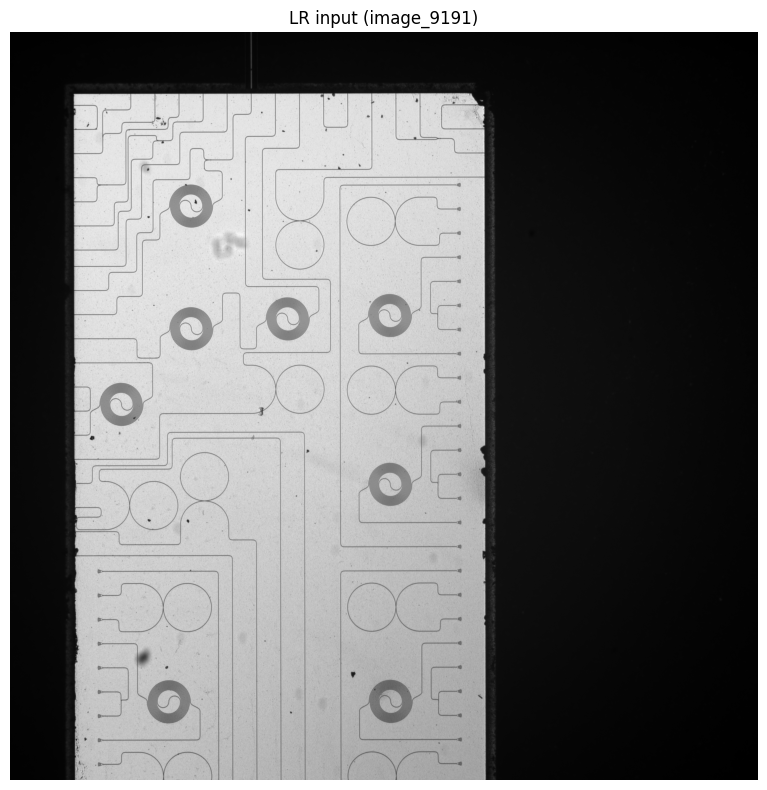

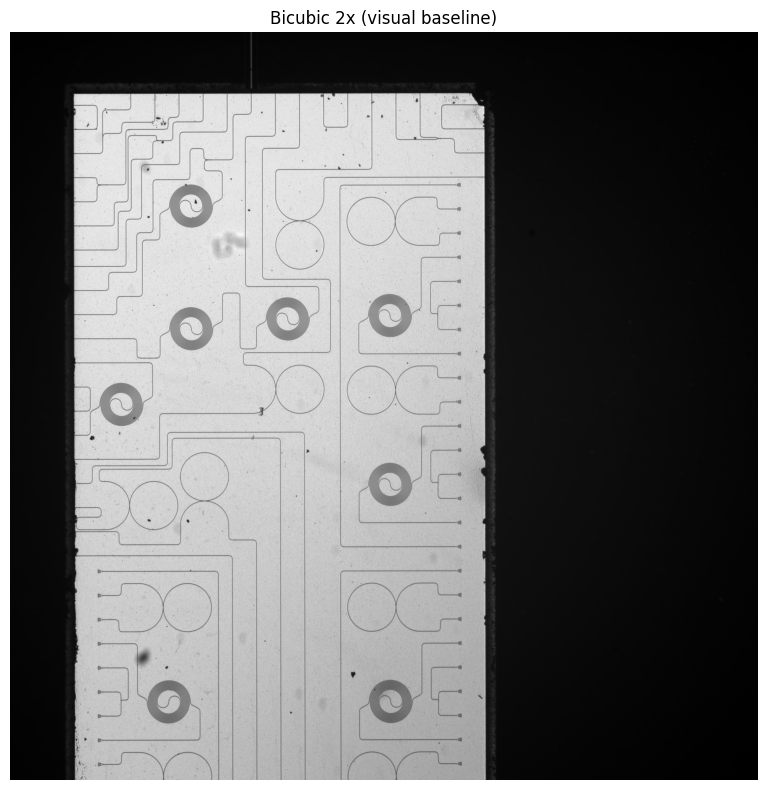

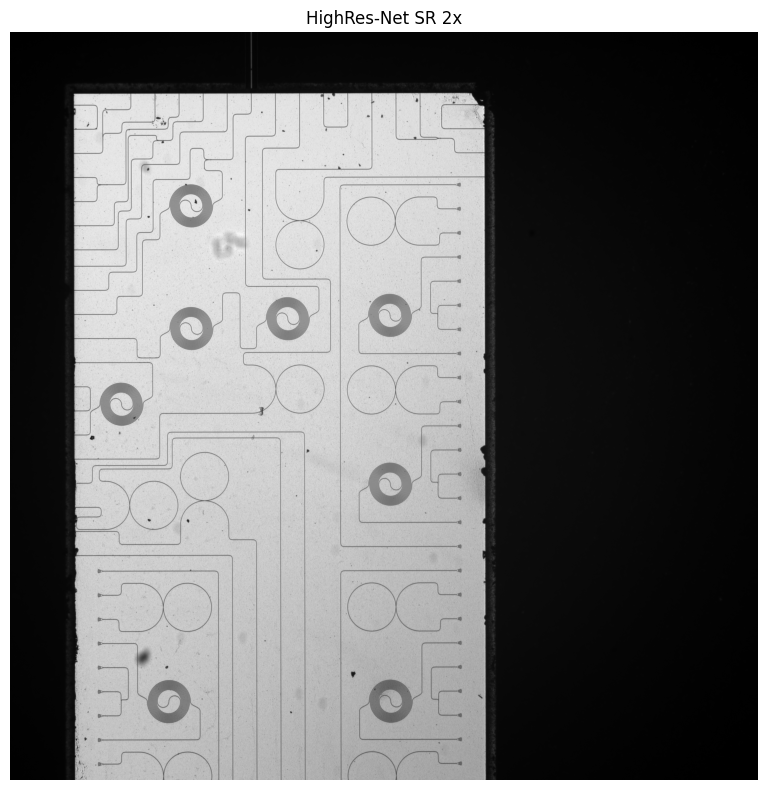

LR shape: (2840, 2840)
Bicubic shape: (5680, 5680)
SR shape: (5680, 5680)


In [7]:
if len(results) == 0:
    print('No results to display. Run the inference cell first.')
else:
    sample_index = 0
    item = results[sample_index]

    # Show each image independently to inspect details without panel resampling artifacts.
    plt.figure(figsize=(8, 8))
    plt.imshow(item['lr_first'], cmap='gray')
    plt.title(f"LR input ({item['name']})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.imshow(item['lr_bicubic'], cmap='gray')
    plt.title('Bicubic 2x (visual baseline)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.imshow(item['sr'], cmap='gray')
    plt.title('HighRes-Net SR 2x')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"LR shape: {item['lr_first'].shape}")
    print(f"Bicubic shape: {item['lr_bicubic'].shape}")
    print(f"SR shape: {item['sr'].shape}")